<a href="https://colab.research.google.com/github/idouglas237020/CS4410/blob/main/Ingram_Douglas_Exercise_15_8_Iris_Hyperparameter_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercise 15.8 - Classification With the Iris Dataset

Hyperparameter Tuning

In [18]:
%matplotlib inline

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
import matplotlib.pyplot as plt
import numpy as np

In [19]:
iris = load_iris()

X = iris.data
y = iris.target

In [20]:
X.shape

(150, 4)

In [21]:
y.shape

(150,)

In [22]:
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10)
    k_scores.append(scores.mean())

In [23]:
best_k = k_range[k_scores.index(max(k_scores))]
best_score = max(k_scores)

print("Best k:", best_k)
print("Best cross-validated accuracy:", best_score)

Best k: 13
Best cross-validated accuracy: 0.9800000000000001


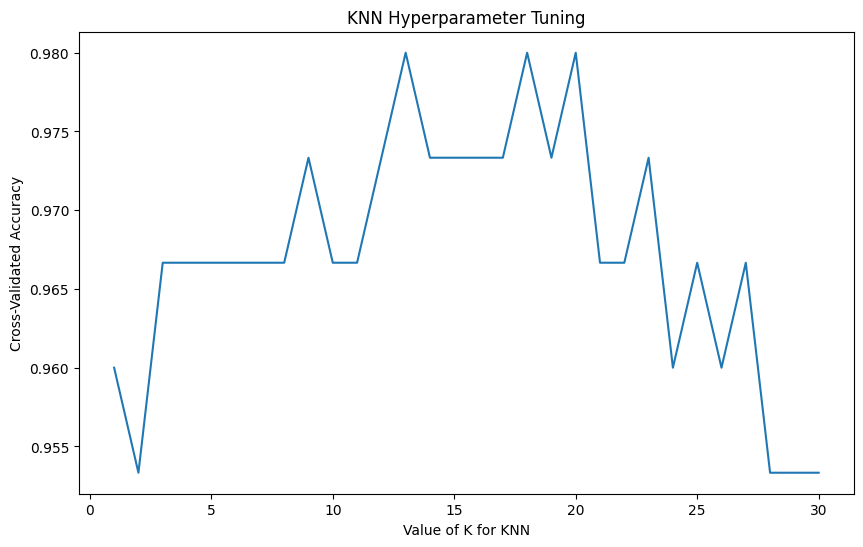

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores)

plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Hyperparameter Tuning')

plt.show()

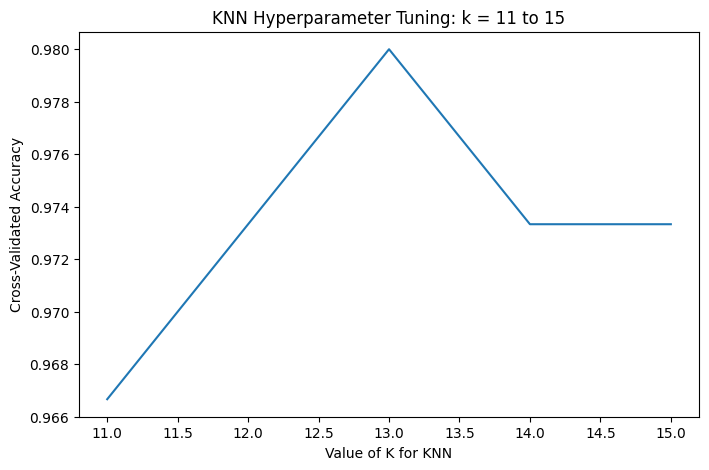

In [25]:
zoom_k = list(range(11, 16))
zoom_scores = [k_scores[k - 1] for k in zoom_k]

plt.figure(figsize=(8, 5))
plt.plot(zoom_k, zoom_scores)

plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Hyperparameter Tuning: k = 11 to 15')

plt.show()

In [26]:
param_grid = {'n_neighbors': range(1, 31)}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=10
)

grid.fit(X, y)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 31)})

In [27]:
print("Best parameter:", grid.best_params_)
print("Best cross-validated accuracy:", grid.best_score_)

Best parameter: {'n_neighbors': 13}
Best cross-validated accuracy: 0.9800000000000001
